# Notebook 2: Nonlinear Probabilistic Regression

**Key idea:** We replace the linear function with a neural network. *Everything else stays the same.*

$$y \mid x \sim \mathcal{N}(f_\theta(x),\; \sigma^2) \qquad \text{where } f_\theta = \text{neural network}$$

## 0. Setup

In [1]:
!pip install pyro-ppl -q

You should consider upgrading via the '/Users/zp25hk/Library/CloudStorage/GoogleDrive-andresrmasegosa@gmail.com/My Drive/teaching/2026-Spring/2026-PhD-PML-Claude/.venv/bin/python3 -m pip install --upgrade pip' command.


In [2]:
import torch
import torch.nn as nn
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO
from pyro.optim import Adam
import matplotlib.pyplot as plt

pyro.set_rng_seed(42)
torch.manual_seed(42)
pyro.clear_param_store()

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['font.size'] = 12
FIGURES_DIR = 'figures/'
import os
os.makedirs(FIGURES_DIR, exist_ok=True)


## 1. Nonlinear synthetic data

This time the true relationship is **nonlinear**: $y = \sin(2x) + 0.3x^2 + \varepsilon$

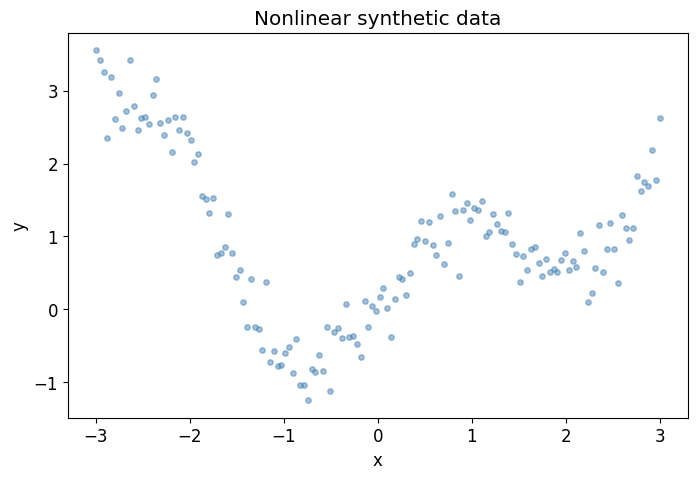

In [3]:
torch.manual_seed(42)
N = 150
sigma_true = 0.3

x_data = torch.linspace(-3, 3, N)
y_data = torch.sin(2 * x_data) + 0.3 * x_data**2 + sigma_true * torch.randn(N)

plt.scatter(x_data.numpy(), y_data.numpy(), alpha=0.5, s=15, color='steelblue')
plt.xlabel('x'); plt.ylabel('y')
plt.title('Nonlinear synthetic data')
plt.savefig(f'{FIGURES_DIR}nonlinear_data.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. The neural network

A standard PyTorch module — nothing Pyro-specific here.

In [4]:
class RegressionNN(nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1)
        )
    def forward(self, x):
        return self.net(x.unsqueeze(-1)).squeeze(-1)

net = RegressionNN()
print(f'Parameters: {sum(p.numel() for p in net.parameters())}')

Parameters: 1153


## 3. Probabilistic model

Compare with Notebook 1 — the **only change** is `mean = net(x)` instead of `mean = w * x + b`.

In [5]:
# Register the neural network parameters with Pyro
pyro.nn.module.to_pyro_module_(net)

def nn_regression_model(x, y=None):
    sigma = pyro.param('sigma', torch.tensor(1.0),
                       constraint=dist.constraints.positive)

    mean = net(x)                      # <-- only change: neural net instead of w*x+b

    with pyro.plate('data', len(x)):
        pyro.sample('obs', dist.Normal(mean, sigma), obs=y)

def empty_guide(x, y=None):
    pass

print('Same structure as Notebook 1: model + empty guide + SVI.')

Same structure as Notebook 1: model + empty guide + SVI.


## 4. Training (almost identical to Notebook 1)

One small addition: `weight_decay` in the optimizer.  
This adds a penalty $\lambda \|\theta\|^2$ to the loss — equivalent to assuming a **Gaussian prior** $\mathcal{N}(0, 1/\lambda)$ on every network weight.  
We will revisit this connection in Block 3; for now, it simply keeps weights small and prevents overfitting.

Step  500 | Loss: 11.37 | sigma=0.262
Step 1000 | Loss: 10.97 | sigma=0.260
Step 1500 | Loss: 10.76 | sigma=0.260
Step 2000 | Loss: 10.47 | sigma=0.260


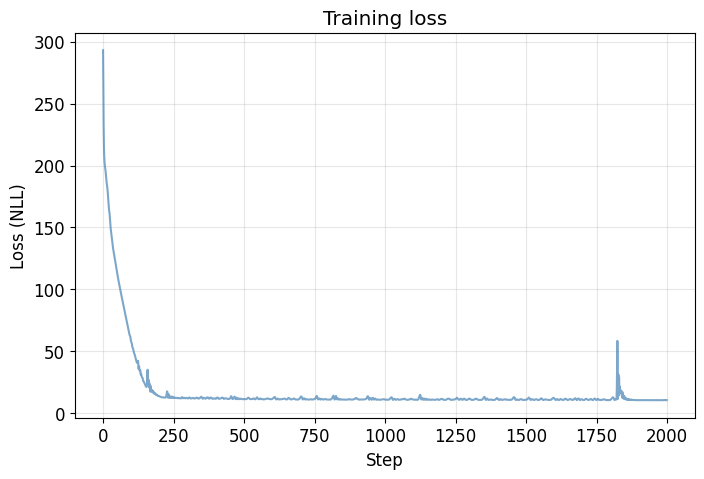

In [6]:
pyro.clear_param_store()
optimizer = Adam({'lr': 0.01, 'weight_decay': 1e-1})  # weight_decay = L2 reg = Gaussian prior on weights
svi = SVI(nn_regression_model, empty_guide, optimizer, loss=Trace_ELBO())

losses = []
for step in range(2000):
    loss = svi.step(x_data, y_data)
    losses.append(loss)
    if (step + 1) % 500 == 0:
        sigma_est = pyro.param('sigma').item()
        print(f'Step {step+1:4d} | Loss: {loss:.2f} | sigma={sigma_est:.3f}')

plt.plot(losses, color='steelblue', alpha=0.7)
plt.xlabel('Step'); plt.ylabel('Loss (NLL)')
plt.title('Training loss'); plt.grid(True, alpha=0.3)
plt.show()

## 5. Predictions with uncertainty

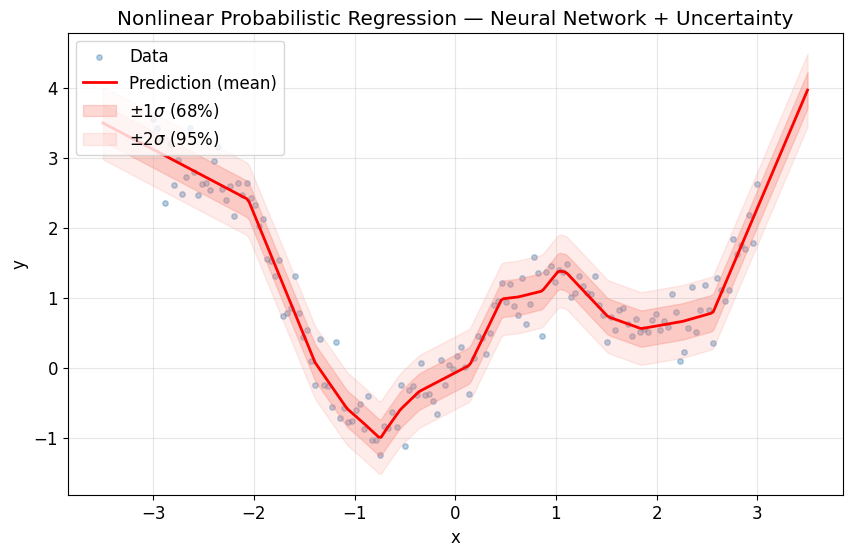

Learned sigma = 0.260 (true = 0.3)


In [7]:
sigma_learned = pyro.param('sigma').item()

x_test = torch.linspace(-3.5, 3.5, 300)
with torch.no_grad():
    y_mean = net(x_test)

plt.figure(figsize=(10, 6))
plt.scatter(x_data.numpy(), y_data.numpy(), alpha=0.4, s=15, color='steelblue', label='Data')
plt.plot(x_test.numpy(), y_mean.numpy(), 'r-', linewidth=2, label='Prediction (mean)')
plt.fill_between(x_test.numpy(),
                 (y_mean - sigma_learned).numpy(),
                 (y_mean + sigma_learned).numpy(),
                 alpha=0.3, color='salmon', label='$\\pm 1\\sigma$ (68%)')
plt.fill_between(x_test.numpy(),
                 (y_mean - 2*sigma_learned).numpy(),
                 (y_mean + 2*sigma_learned).numpy(),
                 alpha=0.15, color='salmon', label='$\\pm 2\\sigma$ (95%)')
plt.xlabel('x'); plt.ylabel('y')
plt.title('Nonlinear Probabilistic Regression — Neural Network + Uncertainty')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.savefig(f'{FIGURES_DIR}nonlinear_regression_with_bands.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Learned sigma = {sigma_learned:.3f} (true = {sigma_true})')

## 6. Takeaway

| | Notebook 1 (linear) | Notebook 2 (neural net) |
|:--|:--|:--|
| **Predictor** | $w^\top x + b$ | Neural network $f_\theta(x)$ |
| **Probabilistic model** | $y \sim \mathcal{N}(wx+b, \sigma^2)$ | $y \sim \mathcal{N}(f_\theta(x), \sigma^2)$ |
| **Pyro code** | Same | Same |
| **Inference** | Same (SVI + MLE) | Same (SVI + MLE) |

The probabilistic framework **does not change** — only the function family does.

**Next:** Block 2 will apply the same pattern to classification.

---

## 7. Exercise: Learning Input-Dependent Uncertainty

So far $\sigma$ has been a **single global scalar** — the model assumes the same noise level everywhere.

But what if the data is **more noisy in some regions than others**?

$$y \mid x \sim \mathcal{N}\!\bigl(f_\theta(x),\; \sigma_\theta(x)^2\bigr)$$

Both the mean **and** the uncertainty are now functions of $x$, learned from data.  
This is called **heteroscedastic regression**.

> **Why does it matter?**  
> A model that knows *where* it is uncertain gives much more useful predictions.  
> In safety-critical settings (robotics, medicine), overconfident regions are dangerous.

### 7.1 A new dataset — noise grows with $|x|$

The true data-generating process is:

$$y = \sin(2x) + 0.3x^2 + \underbrace{(0.1 + 0.4\,|x|)}_{\sigma(x)} \cdot \varepsilon, \qquad \varepsilon \sim \mathcal{N}(0,1)$$

Notice: near $x=0$ the noise is small ($\sigma \approx 0.1$), but near $x=\pm 3$ it is large ($\sigma \approx 1.3$).  
A homoscedastic model (fixed $\sigma$) will be **too uncertain in the center** and **too confident at the edges**.

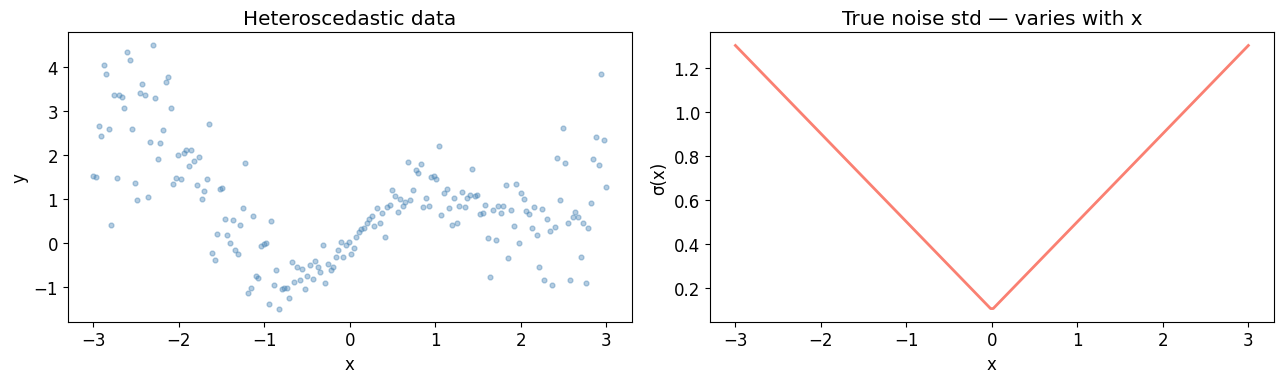

σ at x=0: 0.10   |   σ at x=3: 1.30


In [8]:
torch.manual_seed(0)
N_het = 200

x_het = torch.linspace(-3, 3, N_het)
sigma_true_het = 0.1 + 0.4 * x_het.abs()          # true noise std — depends on x
y_het = torch.sin(2 * x_het) + 0.3 * x_het**2 + sigma_true_het * torch.randn(N_het)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(x_het.numpy(), y_het.numpy(), alpha=0.4, s=12, color='steelblue')
axes[0].set_xlabel('x'); axes[0].set_ylabel('y')
axes[0].set_title('Heteroscedastic data')

axes[1].plot(x_het.numpy(), sigma_true_het.numpy(), color='salmon', linewidth=2)
axes[1].set_xlabel('x'); axes[1].set_ylabel('σ(x)')
axes[1].set_title('True noise std — varies with x')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}heteroscedastic_data.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'σ at x=0: {(0.1 + 0.4*0):.2f}   |   σ at x=3: {(0.1 + 0.4*3):.2f}')

### 7.2 Your task

You need to make **two changes** to the code from Section 3–4:

---

**Change 1 — the network.**  
Instead of returning only `mean`, the network must return **two values**: `mean` and `sigma`.  
The trick for sigma: predict `log_sigma` and then exponentiate it to guarantee positivity.

```
Input x  →  shared layers  →  mean head      →           mean
                            →  log_sigma head → exp(·) →  sigma
```

**Change 2 — the probabilistic model.**  
Remove the global `pyro.param('sigma', ...)`.  
Instead, call `het_net(x)` to get both `mean, sigma = het_net(x)` and use them directly in the `Normal`.

---

**Hint — which lines to touch:**

| What to change | Where |
|:---|:---|
| Network class: add a second output head | `HeteroscedasticNN.__init__` and `forward` |
| Model function: remove global sigma, use `het_net(x)` | `het_regression_model` |
| Training loop | nothing changes — identical to before |

**Sanity check:** after training, run the visualisation cell below. The learned $\sigma(x)$ should roughly follow the true $\sigma(x) = 0.1 + 0.4|x|$ curve.

In [9]:
# ============================================================
# EXERCISE — fill in the parts marked  ???
# ============================================================

class HeteroscedasticNN(nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        # Shared trunk — same as before
        self.shared = nn.Sequential(
            nn.Linear(1, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
        )
        # Two output heads: one for the mean, one for log(sigma)
        self.mean_head      = nn.Linear(hidden, 1)
        self.log_sigma_head = ???   # TODO: same shape as mean_head

    def forward(self, x):
        h         = self.shared(x.unsqueeze(-1))   # shared representation
        mean      = self.mean_head(h).squeeze(-1)
        log_sigma = ???                             # TODO: apply log_sigma_head, then squeeze
        sigma     = torch.exp(log_sigma)            # exp ensures sigma > 0 always
        return mean, sigma


het_net = HeteroscedasticNN()
pyro.nn.module.to_pyro_module_(het_net)

# ---- probabilistic model ----
def het_regression_model(x, y=None):
    # TODO: remove the global pyro.param('sigma', ...) line — sigma now comes from the network
    # TODO: unpack both outputs:
    mean, sigma = ???

    with pyro.plate('data', len(x)):
        pyro.sample('obs', dist.Normal(mean, sigma), obs=y)


# ---- training (nothing changes here) ----
pyro.clear_param_store()
het_optimizer = Adam({'lr': 0.01, 'weight_decay': 1e-3})
het_svi = SVI(het_regression_model, empty_guide, het_optimizer, loss=Trace_ELBO())

het_losses = []
for step in range(3000):
    loss = het_svi.step(x_het, y_het)
    het_losses.append(loss)
    if (step + 1) % 1000 == 0:
        print(f'Step {step+1:4d} | Loss: {loss:.2f}')

plt.plot(het_losses, color='steelblue', alpha=0.7)
plt.xlabel('Step'); plt.ylabel('Loss (NLL)')
plt.title('Heteroscedastic training loss'); plt.grid(True, alpha=0.3)
plt.show()

SyntaxError: invalid syntax (3234100546.py, line 17)

### 7.3 Visualisation

Once your model trains, run this cell to check results.  
**The learned $\sigma(x)$ should roughly follow the true $\sigma(x) = 0.1 + 0.4|x|$ curve.**

In [ ]:
x_test_het = torch.linspace(-3.5, 3.5, 300)
with torch.no_grad():
    y_mean_het, y_sigma_het = het_net(x_test_het)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: predictions with uncertainty bands
axes[0].scatter(x_het.numpy(), y_het.numpy(), alpha=0.3, s=12, color='steelblue', label='Data')
axes[0].plot(x_test_het.numpy(), y_mean_het.numpy(), 'r-', lw=2, label='Predicted mean')
axes[0].fill_between(x_test_het.numpy(),
                     (y_mean_het - y_sigma_het).numpy(),
                     (y_mean_het + y_sigma_het).numpy(),
                     alpha=0.3, color='salmon', label='±1σ(x)')
axes[0].fill_between(x_test_het.numpy(),
                     (y_mean_het - 2*y_sigma_het).numpy(),
                     (y_mean_het + 2*y_sigma_het).numpy(),
                     alpha=0.12, color='salmon', label='±2σ(x)')
axes[0].set_xlabel('x'); axes[0].set_ylabel('y')
axes[0].set_title('Heteroscedastic predictions')
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

# Right: learned σ(x) vs true σ(x)
sigma_true_test = 0.1 + 0.4 * x_test_het.abs()
axes[1].plot(x_test_het.numpy(), sigma_true_test.numpy(), 'k--', lw=2, label='True σ(x)')
axes[1].plot(x_test_het.numpy(), y_sigma_het.numpy(), 'r-', lw=2, label='Learned σ(x)')
axes[1].set_xlabel('x'); axes[1].set_ylabel('σ(x)')
axes[1].set_title('Learned vs true noise std')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}heteroscedastic_result.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.4 Solution

<details>
<summary><b>Click to reveal — try it yourself first!</b></summary>

```python
class HeteroscedasticNN(nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(1, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
        )
        self.mean_head      = nn.Linear(hidden, 1)
        self.log_sigma_head = nn.Linear(hidden, 1)   # ← same shape as mean_head

    def forward(self, x):
        h         = self.shared(x.unsqueeze(-1))
        mean      = self.mean_head(h).squeeze(-1)
        log_sigma = self.log_sigma_head(h).squeeze(-1)   # ← apply head, squeeze
        sigma     = torch.exp(log_sigma)
        return mean, sigma


def het_regression_model(x, y=None):
    mean, sigma = het_net(x)   # ← no global param; both come from the network

    with pyro.plate('data', len(x)):
        pyro.sample('obs', dist.Normal(mean, sigma), obs=y)
```

**Key insight:** the NLL of a heteroscedastic Gaussian is

$$-\log p(y \mid x) = \frac{(y - \mu_\theta(x))^2}{2\,\sigma_\theta(x)^2} + \log \sigma_\theta(x) + \text{const}$$

The $\log\sigma_\theta(x)$ term penalises the model for predicting unnecessarily large uncertainty, so the network only "uses" uncertainty where the data actually requires it. Both heads are trained simultaneously by minimising this loss.

</details>